# Notebook 0 — Group Preprocessing

**Practical Business Analytics — COM3032 / COMM074 Coursework**

This notebook is the group-level deliverable for Sections 1 and 2 of the report. It prepares the Telco Customer Churn dataset for the individual modelling notebooks.

It covers:

- **Section 1 — Introduction and Business Understanding**
- **Section 2 — Data Pre-processing and Exploration**

The main output from this notebook is:

- `telco_processed.csv`

This processed file is used by the five individual modelling notebooks, NB1–NB5. Each individual notebook trains one primary model and compares it against the shared Logistic Regression benchmark.

The workflow follows the CRISP-DM structure:

Business Understanding → Data Understanding → Data Preparation → Modelling and Evaluation → Discussion and Recommendations

In this project, NB0 covers the first three stages. Modelling and evaluation are completed in NB1–NB5, while the final dashboard, discussion and recommendations are completed in NB6.

## 1. Introduction — Business Understanding

### 1.1 Business problem

**Telco Customer Churn**

*Which customers are likely to leave the service, and what factors are linked with that churn risk?*

Customer churn is an important business problem for telecom companies because losing existing customers can reduce revenue and increase the need for new customer acquisition. In practice, retaining existing customers is usually more cost-effective than replacing them. A churn prediction model can help the retention team prioritise customers who are more likely to leave and take action earlier.

**Dataset:** IBM Telco Customer Churn dataset — 7,043 customers and 21 original features covering demographics, account information, subscribed services and charges.

### 1.2 Research question

Can we predict customer churn using customer account, service and charge-related attributes, and identify the strongest drivers of churn risk?

### 1.3 Techniques planned

The group evaluates five supervised classification algorithms, with one primary model assigned to each individual notebook:

- Decision Tree
- Gaussian Naive Bayes
- k-Nearest Neighbours
- Multi-Layer Perceptron
- Linear SVM

Each notebook also uses **Logistic Regression as the shared benchmark model**. This gives every primary model the same comparison point.

All notebooks use the same evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- MCC
- Overfit Gap

### 1.4 CRISP-DM mapping

| Phase | Where in this project |
|---|---|
| Business Understanding | Section 1 of this notebook |
| Data Understanding | Initial loading, inspection, data dictionary and exploratory analysis in NB0 |
| Data Preparation | Cleaning, feature engineering, encoding, imbalance checks and processed file creation in NB0 |
| Modelling | Individual notebooks NB1–NB5 |
| Evaluation | Individual notebook evaluation sections and the group dashboard in NB6 |
| Discussion and Recommendations | NB6 dashboard and final report |

## 2. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

print('Environment ready.')
print('pandas:', pd.__version__, '| numpy:', np.__version__)

Environment ready.
pandas: 3.0.3 | numpy: 2.3.4


## 3. Data Pre-processing and Exploration

This section prepares the Telco churn dataset for modelling. The aim is to create a clean, encoded and model-ready dataset while documenting the key preprocessing decisions.

The section follows this structure:

1. Load and inspect the raw data
2. Create a data dictionary
3. Explore the target and key customer features
4. Clean missing or invalid values
5. Engineer business-relevant features
6. Encode categorical variables
7. Check feature relationships with the churn target
8. Use PCA for visual exploration
9. Compare class imbalance handling strategies
10. Explain scaling and leakage control
11. Save the final processed file as `telco_processed.csv`

Scaling is not fitted in this notebook. It is handled inside the individual modelling notebooks after the train/test split, so that the scaler is fitted only on training data and no test-set information leaks into preprocessing.

### 3.1 Load and inspect

The Telco dataset is loaded from the raw CSV file. The first inspection checks the dataset shape, preview rows, data types, missing values and duplicate rows. This gives a clear starting point before cleaning and feature engineering.

In [2]:
telco_raw = pd.read_csv('Telco-Customer-Churn.csv')

print('Telco dataset loaded successfully.')
print('Shape:', telco_raw.shape)

print('\nFirst 5 rows:')
display(telco_raw.head())

print('\nData types:')
display(telco_raw.dtypes.to_frame('dtype'))

print('\nMissing values:')
missing_values = telco_raw.isna().sum()
display(missing_values[missing_values > 0].to_frame('missing_count'))

print('\nDuplicate rows:', telco_raw.duplicated().sum())

Telco dataset loaded successfully.
Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data types:


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Missing values:


,missing_count



Duplicate rows: 0


In [3]:
print('Missing values per column (non-zero only):')

missing_counts = telco_raw.isna().sum()
non_zero_missing = missing_counts[missing_counts > 0]

if len(non_zero_missing) == 0:
    print('(no nulls reported)')
else:
    display(non_zero_missing.to_frame('missing_count'))

# TotalCharges is stored as object even though it should be numeric.
# This suggests hidden non-numeric entries, usually blank strings.
totalcharges_numeric = pd.to_numeric(telco_raw['TotalCharges'], errors='coerce')
bad_totalcharges_mask = totalcharges_numeric.isna()

print('\nHidden non-numeric entries in TotalCharges:')
print(f'Rows affected: {bad_totalcharges_mask.sum()} ({bad_totalcharges_mask.mean() * 100:.2f}%)')

print('\nSample affected rows:')
display(
    telco_raw.loc[
        bad_totalcharges_mask,
        ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
    ].head()
)

Missing values per column (non-zero only):
(no nulls reported)

Hidden non-numeric entries in TotalCharges:
Rows affected: 11 (0.16%)

Sample affected rows:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No


### 3.2 Data dictionary

| Feature | Type | Description |
|---|---|---|
| `customerID` | string | Unique customer identifier — dropped before modelling because it has no generalisable predictive value |
| `gender` | binary categorical | Male / Female |
| `SeniorCitizen` | binary integer | 1 if customer is a senior citizen, otherwise 0 |
| `Partner`, `Dependents` | binary categorical | Whether the customer has a partner or dependents |
| `tenure` | numeric integer | Number of months the customer has stayed with the company |
| `PhoneService`, `MultipleLines` | categorical | Phone service availability and number of phone lines |
| `InternetService` | categorical | Type of internet service: DSL, Fiber optic, or No internet service |
| `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | categorical | Optional service add-ons, recorded as Yes / No / No internet service |
| `Contract` | categorical | Contract type: Month-to-month, One year, or Two year |
| `PaperlessBilling` | binary categorical | Whether the customer uses paperless billing |
| `PaymentMethod` | categorical | Customer payment method |
| `MonthlyCharges` | numeric float | Customer’s current monthly bill |
| `TotalCharges` | numeric after cleaning | Lifetime charges to date; initially loaded as text and converted to numeric during cleaning |
| `Churn` | binary target | Whether the customer churned; converted from Yes / No to 1 / 0 |

### 3.3 Initial exploration

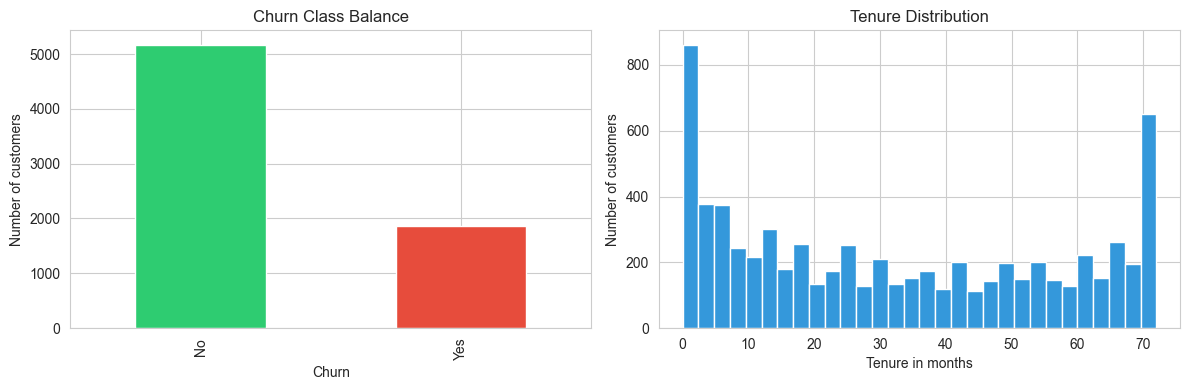

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Churn rate: 0.265
Interpretation: Churners are the minority class, so Accuracy alone may be misleading. The modelling notebooks should also use Precision, Recall, F1-score, ROC-AUC, PR-AUC and MCC.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn class balance
telco_raw['Churn'].value_counts().plot.bar(
    ax=axes[0],
    color=['#2ecc71', '#e74c3c']
)

axes[0].set_title('Churn Class Balance')
axes[0].set_ylabel('Number of customers')
axes[0].set_xlabel('Churn')

# Tenure distribution
telco_raw['tenure'].hist(
    bins=30,
    ax=axes[1],
    color='#3498db',
    edgecolor='white'
)

axes[1].set_title('Tenure Distribution')
axes[1].set_xlabel('Tenure in months')
axes[1].set_ylabel('Number of customers')

plt.tight_layout()
plt.show()

churn_summary = pd.DataFrame({
    'Count': telco_raw['Churn'].value_counts(),
    'Percentage': (telco_raw['Churn'].value_counts(normalize=True) * 100).round(2)
})

display(churn_summary)

churn_rate = (telco_raw['Churn'] == 'Yes').mean()
print(f'Churn rate: {churn_rate:.3f}')

print(
    'Interpretation: Churners are the minority class, so Accuracy alone may be misleading. '
    'The modelling notebooks should also use Precision, Recall, F1-score, ROC-AUC, PR-AUC and MCC.'
)

In [5]:
numeric_summary = telco_raw[['tenure', 'MonthlyCharges']].describe().round(2)

display(numeric_summary)

print(
    "Interpretation: tenure and MonthlyCharges show the spread of customer lifecycle length "
    "and current billing amount before modelling. TotalCharges is not included here yet because "
    "it is still stored as text and is converted to numeric during cleaning."
)

,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


Interpretation: tenure and MonthlyCharges show the spread of customer lifecycle length and current billing amount before modelling. TotalCharges is not included here yet because it is still stored as text and is converted to numeric during cleaning.


Churn rate by contract type:


,Contract,Churn_Rate_%
0,Month-to-month,42.7
1,One year,11.3
2,Two year,2.8


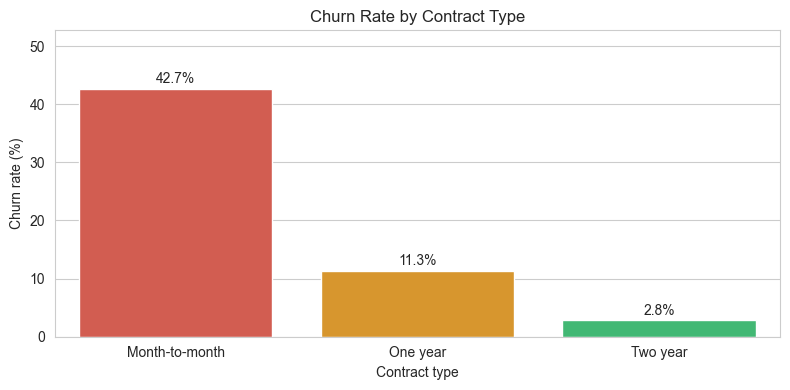

Interpretation: Month-to-month customers have a much higher churn rate than customers on longer contracts. This makes contract type an important business feature for churn analysis.


In [6]:
# Churn rate by contract type

contract_churn = (
    telco_raw
    .groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean())
    .sort_values(ascending=False)
    .reset_index(name='Churn_Rate')
)

contract_churn['Churn_Rate_%'] = (contract_churn['Churn_Rate'] * 100).round(1)

print('Churn rate by contract type:')
display(contract_churn[['Contract', 'Churn_Rate_%']])

plt.figure(figsize=(8, 4))

sns.barplot(
    data=contract_churn,
    x='Contract',
    y='Churn_Rate_%',
    palette=['#e74c3c', '#f39c12', '#2ecc71']
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract type')
plt.ylabel('Churn rate (%)')
plt.ylim(0, contract_churn['Churn_Rate_%'].max() + 10)

for i, value in enumerate(contract_churn['Churn_Rate_%']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print(
    'Interpretation: Month-to-month customers have a much higher churn rate than customers '
    'on longer contracts. This makes contract type an important business feature for churn analysis.'
)

### Churn by contract type

Contract type is checked because it represents customer commitment. Customers on month-to-month contracts are usually easier to lose, while longer contracts may reduce churn risk.Month-to-month customers churn at around 43%, versus around 3% for two-year contracts. This is the strongest categorical signal in the dataset.

### 3.4 Cleaning

Two cleaning steps are applied. First, `customerID` is removed because it is a unique identifier and would not generalise to new customers. Second, `TotalCharges` is converted from text to numeric. The conversion reveals a small number of blank values, which are removed before modelling.

In [7]:
telco = telco_raw.copy()

# Drop customerID because it is only a unique identifier.
# It does not provide generalisable predictive information.
telco = telco.drop(columns=['customerID'])

# Convert TotalCharges to numeric.
# It was loaded as text because a small number of rows contain blank values.
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

blank_totalcharges = telco['TotalCharges'].isna().sum()
print(f'Rows with blank/non-numeric TotalCharges: {blank_totalcharges}')

# Drop rows with missing TotalCharges.
# This affects only a very small proportion of the dataset.
telco = telco.dropna(subset=['TotalCharges']).reset_index(drop=True)

print(f'After cleaning: {telco.shape}')
print(f'Remaining missing values: {telco.isna().sum().sum()}')

Rows with blank/non-numeric TotalCharges: 11
After cleaning: (7032, 20)
Remaining missing values: 0


Cleaning choices:
- `customerID` is unique per row and would let a model overfit to training rows; dropped.
- Blank `TotalCharges` rows are all new customers with `tenure=0`. Imputing with 0 would conflate "no data yet" with "free customer". The affected rows are well under 1% of the data, so they are dropped.

### 3.5 Feature engineering

Five derived features are added to make the raw Telco variables more business meaningful. These features are designed to capture customer lifecycle stage, service engagement, spending behaviour and contract commitment.

| Feature | Definition | Interpretation |
|---|---|---|
| `TenureBucket` | Discretised tenure: 0–12m, 13–24m, 25–48m, 49–60m, 61m+ | Customer lifecycle stage |
| `ServicesCount` | Number of subscribed “Yes” services across service-related columns | Engagement breadth and possible switching effort |
| `AvgMonthlySpend` | `TotalCharges / max(tenure, 1)` | Historical average monthly spend |
| `ChargesPerService` | `MonthlyCharges / max(ServicesCount, 1)` | Price pressure relative to the number of services held |
| `IsLongTermContract` | 1 if `Contract` is One year or Two year, otherwise 0 | Contract commitment signal |

These features are created before one-hot encoding so they are included in the final modelling dataset. The aim is to represent customer behaviour in a way that is closer to the business problem of churn prediction.

In [8]:
# 1. Tenure buckets
def tenure_bucket(t):
    if t <= 12:
        return '0-12m'
    elif t <= 24:
        return '13-24m'
    elif t <= 48:
        return '25-48m'
    elif t <= 60:
        return '49-60m'
    else:
        return '61m+'

telco['TenureBucket'] = telco['tenure'].apply(tenure_bucket)

# 2. ServicesCount — count the number of subscribed services
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PhoneService', 'MultipleLines'
]

telco['ServicesCount'] = (telco[service_cols] == 'Yes').sum(axis=1)

# 3. AvgMonthlySpend — historical average monthly spend
telco['AvgMonthlySpend'] = telco['TotalCharges'] / telco['tenure'].clip(lower=1)

# 4. ChargesPerService — monthly charge relative to services held
telco['ChargesPerService'] = telco['MonthlyCharges'] / telco['ServicesCount'].clip(lower=1)

# 5. IsLongTermContract — binary contract commitment flag
telco['IsLongTermContract'] = telco['Contract'].isin(['One year', 'Two year']).astype(int)

print('Engineered features sample:')
display(
    telco[
        [
            'tenure',
            'TenureBucket',
            'ServicesCount',
            'AvgMonthlySpend',
            'ChargesPerService',
            'IsLongTermContract'
        ]
    ].head().round(2)
)

# Quick sanity check: correlation between engineered numeric features and Churn
churn_int = (telco['Churn'] == 'Yes').astype(int)

engineered_corr = pd.DataFrame({
    'Feature': [
        'ServicesCount',
        'AvgMonthlySpend',
        'ChargesPerService',
        'IsLongTermContract'
    ],
    'Correlation_with_Churn': [
        telco['ServicesCount'].corr(churn_int),
        telco['AvgMonthlySpend'].corr(churn_int),
        telco['ChargesPerService'].corr(churn_int),
        telco['IsLongTermContract'].corr(churn_int)
    ]
})

engineered_corr['Correlation_with_Churn'] = engineered_corr['Correlation_with_Churn'].round(3)

display(
    engineered_corr
    .sort_values('Correlation_with_Churn', key=abs, ascending=False)
    .reset_index(drop=True)
)

Engineered features sample:


,tenure,TenureBucket,ServicesCount,AvgMonthlySpend,ChargesPerService,IsLongTermContract
0,1,0-12m,1,29.85,29.85,0
1,34,25-48m,3,55.57,18.98,1
2,2,0-12m,3,54.08,17.95,0
3,45,25-48m,3,40.91,14.10,1
4,2,0-12m,1,75.82,70.70,0


,Feature,Correlation_with_Churn
0,IsLongTermContract,-0.405
1,ChargesPerService,0.313
2,AvgMonthlySpend,0.192
3,ServicesCount,-0.067


**Why these features help:**

- `IsLongTermContract` captures the main contract commitment signal in one column. This is useful for linear models because it gives a cleaner coefficient, and useful for tree models because a single split can separate short-term and long-term contract customers.

- `ChargesPerService` is a ratio feature that combines monthly charges with service engagement. The original columns show cost and service count separately, but this feature captures how expensive a customer’s plan appears relative to the number of services they use. This may help identify customers experiencing higher price pressure.

- `ServicesCount` acts as a proxy for customer engagement and switching effort. Customers with more bundled services may be less likely to leave because moving several services to another provider is usually more difficult than cancelling one service.

The original one-hot service columns are kept alongside `ServicesCount`. This allows the models to use both the overall engagement level and the specific service breakdown, depending on which pattern is more predictive.

### 3.6 Encoding

In [9]:
# Target: Churn Yes/No -> 1/0
telco['Churn'] = (telco['Churn'] == 'Yes').astype(int)

# Binary categorical variables are mapped directly to 0/1.
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    telco[col] = telco[col].map(binary_map)

# Multi-category variables are one-hot encoded.
# drop_first=True avoids perfect multicollinearity between dummy columns.
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
    'TenureBucket'
]

telco = pd.get_dummies(
    telco,
    columns=multi_cols,
    drop_first=True
)

# Convert boolean dummy columns to integers for consistency across modelling notebooks.
bool_cols = telco.select_dtypes(include='bool').columns
telco[bool_cols] = telco[bool_cols].astype(int)

print(f'Final processed Telco shape: {telco.shape}')
print(f'Feature count excluding Churn target: {telco.shape[1] - 1}')
print(f'Remaining missing values: {telco.isna().sum().sum()}')

display(telco.head())

Final processed Telco shape: (7032, 39)
Feature count excluding Churn target: 38
Remaining missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureBucket_13-24m,TenureBucket_25-48m,TenureBucket_49-60m,TenureBucket_61m+
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,1,0,0,0,1,0,1,0,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,1,0,0,0,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,1,0,0,0,0,0,1,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,1,0,0,0,0,0


**Encoding choices:**

- Binary mapping for Yes/No fields keeps the feature space smaller without losing information.
- Multi-category variables are one-hot encoded using `drop_first=True`. This avoids the dummy-variable trap and is helpful for linear models such as Logistic Regression and Linear SVM.
- The engineered `TenureBucket` feature is also one-hot encoded so that lifecycle groups can be used by all models.
- Scaling is deferred to the individual modelling notebooks. For models that require scaling, the scaler is fitted only on the training data and then applied to validation/test data. This prevents test-set leakage.

### 3.7 Correlation with churn

Correlation is used as an initial check to identify which encoded or numeric features are most strongly associated with churn. This does not prove causation, but it helps confirm that the processed features contain useful predictive signal before modelling.

,Correlation_with_Churn,Abs_Correlation
IsLongTermContract,-0.405,0.405
tenure,-0.354,0.354
ChargesPerService,0.313,0.313
InternetService_Fiber optic,0.307,0.307
Contract_Two year,-0.302,0.302
PaymentMethod_Electronic check,0.301,0.301
StreamingTV_No internet service,-0.228,0.228
TechSupport_No internet service,-0.228,0.228
DeviceProtection_No internet service,-0.228,0.228
StreamingMovies_No internet service,-0.228,0.228


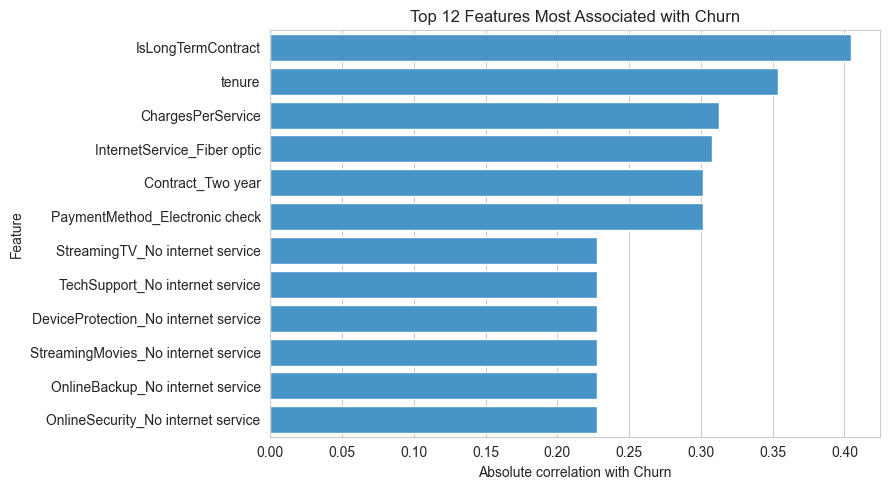

Note: correlation is used only as an initial exploration tool. It captures linear relationships, while later models can also capture non-linear patterns and feature interactions.


In [10]:
corr = (
    telco.corr(numeric_only=True)['Churn']
    .drop('Churn')
    .sort_values(key=abs, ascending=False)
    .head(12)
)

corr_table = corr.to_frame('Correlation_with_Churn')
corr_table['Abs_Correlation'] = corr_table['Correlation_with_Churn'].abs()

display(corr_table.round(3))

plt.figure(figsize=(9, 5))

sns.barplot(
    x='Abs_Correlation',
    y=corr_table.index,
    data=corr_table,
    color='#3498db'
)

plt.title('Top 12 Features Most Associated with Churn')
plt.xlabel('Absolute correlation with Churn')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(
    'Note: correlation is used only as an initial exploration tool. '
    'It captures linear relationships, while later models can also capture non-linear patterns and feature interactions.'
)

### 3.8 PCA visualisation

PCA is used as an exploratory visualisation to check whether churn and non-churn customers separate clearly in a two-dimensional projection.

The features are scaled before PCA because PCA is sensitive to feature magnitude. This scaling is used only for the visualisation in this cell. It is not saved into `telco_processed.csv`. In the modelling notebooks, scaling is fitted only on the training data after the split to avoid data leakage.

PC1 explains 30.0% of variance
PC2 explains 14.3% of variance
Cumulative PC1 + PC2: 44.4%


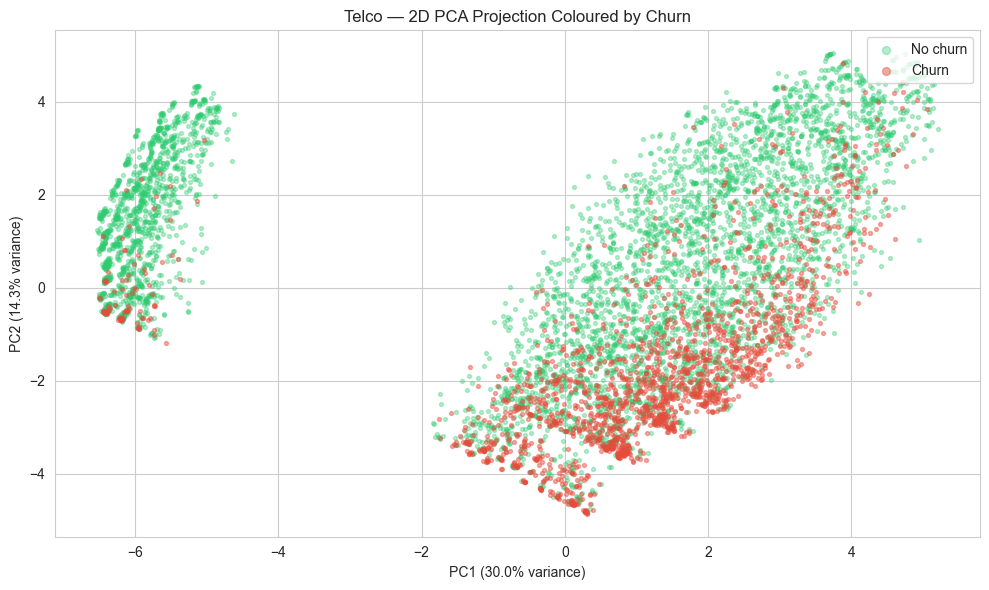

Top 5 contributors to PC1:


,Absolute loading
MonthlyCharges,0.273
AvgMonthlySpend,0.272
InternetService_No,0.272
OnlineBackup_No internet service,0.272
StreamingTV_No internet service,0.272


Top 5 contributors to PC2:


,Absolute loading
tenure,0.352
IsLongTermContract,0.345
ChargesPerService,0.297
Contract_Two year,0.294
TenureBucket_61m+,0.284


In [11]:
# PCA visualisation only
# Scaling is applied here because PCA is scale-sensitive.
# This scaled matrix is not saved and does not affect the modelling notebooks.

X_pca = telco.drop(columns=['Churn'])
y_pca = telco['Churn']

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(X_pca_scaled)

ev = pca.explained_variance_ratio_

print(f'PC1 explains {ev[0] * 100:.1f}% of variance')
print(f'PC2 explains {ev[1] * 100:.1f}% of variance')
print(f'Cumulative PC1 + PC2: {ev.sum() * 100:.1f}%')

plt.figure(figsize=(10, 6))

plt.scatter(
    proj[y_pca == 0, 0],
    proj[y_pca == 0, 1],
    s=8,
    alpha=0.35,
    color='#2ecc71',
    label='No churn'
)

plt.scatter(
    proj[y_pca == 1, 0],
    proj[y_pca == 1, 1],
    s=8,
    alpha=0.45,
    color='#e74c3c',
    label='Churn'
)

plt.xlabel(f'PC1 ({ev[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({ev[1] * 100:.1f}% variance)')
plt.title('Telco — 2D PCA Projection Coloured by Churn')
plt.legend(loc='upper right', markerscale=2)
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X_pca.columns
)

print('Top 5 contributors to PC1:')
display(
    loadings['PC1']
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .round(3)
    .to_frame('Absolute loading')
)

print('Top 5 contributors to PC2:')
display(
    loadings['PC2']
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .round(3)
    .to_frame('Absolute loading')
)

The PCA plot shows substantial overlap between churners and non-churners in the first two principal components. This suggests that churn is not separated by one simple two-dimensional pattern, so the modelling notebooks use the full processed feature set rather than reducing the data to PC1 and PC2.

Churners and non-churners overlap substantially in the first two principal components. The first two PCs explain only part of the total variance, so the churn signal is not captured by a simple two-dimensional projection.

Some local structure is visible, but there is no clean visual separation. This supports the decision to compare different model families, including linear, tree-based, distance-based and neural models, rather than relying on one simple boundary or reducing the data to PC1 and PC2.

### 3.9 Class imbalance — comparison of strategies

The Telco dataset has a churn rate of around 26.5%, so the positive churn class is the minority class. This is not severe imbalance, but it is enough that Accuracy alone could be misleading.

We compare three imbalance-handling options using Logistic Regression as a simple baseline:

1. **No correction** — keep the original class distribution. This is simple, but the model may pay less attention to the minority churn class.
2. **`class_weight='balanced'`** — increase the weight given to churn cases during training without creating new records.
3. **SMOTE** — generate synthetic minority-class examples by interpolating between existing churners in the training data.

The key methodological point is that SMOTE is applied to the training set only, after the train/test split. Applying SMOTE before splitting would allow synthetic information to leak into the test set and would make the evaluation unreliable.

This comparison helps decide whether imbalance handling improves Recall, F1-score and PR-AUC without relying on Accuracy alone.

In [12]:
X_imb = telco.drop(columns=['Churn'])
y_imb = telco['Churn']

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb,
    y_imb,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_imb
)

scaler_imb = StandardScaler()
X_train_imb_s = scaler_imb.fit_transform(X_train_imb)
X_test_imb_s = scaler_imb.transform(X_test_imb)


def quick_score(X_train, y_train, X_test, y_test, label, class_weight=None):
    model = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight=class_weight
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Strategy': label,
        'Train positive rate': np.mean(y_train),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    }


rows = []

# 1. No correction
rows.append(
    quick_score(
        X_train_imb_s,
        y_train_imb,
        X_test_imb_s,
        y_test_imb,
        'No correction'
    )
)

# 2. class_weight='balanced'
rows.append(
    quick_score(
        X_train_imb_s,
        y_train_imb,
        X_test_imb_s,
        y_test_imb,
        "class_weight='balanced'",
        class_weight='balanced'
    )
)

# 3. SMOTE on training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imb_s, y_train_imb)

rows.append(
    quick_score(
        X_train_smote,
        y_train_smote,
        X_test_imb_s,
        y_test_imb,
        'SMOTE (training only)'
    )
)

imbalance_df = pd.DataFrame(rows)

print('Class-imbalance handling comparison — Logistic Regression baseline on Telco:')
display(imbalance_df.round(4))

Class-imbalance handling comparison — Logistic Regression baseline on Telco:


,Strategy,Train positive rate,Precision,Recall,F1,ROC-AUC,PR-AUC
0,No correction,0.2658,0.6364,0.5241,0.5748,0.8349,0.6286
1,class_weight='balanced',0.2658,0.4892,0.7861,0.6031,0.8340,0.6241
2,SMOTE (training only),0.5000,0.5009,0.7861,0.6119,0.8321,0.6265


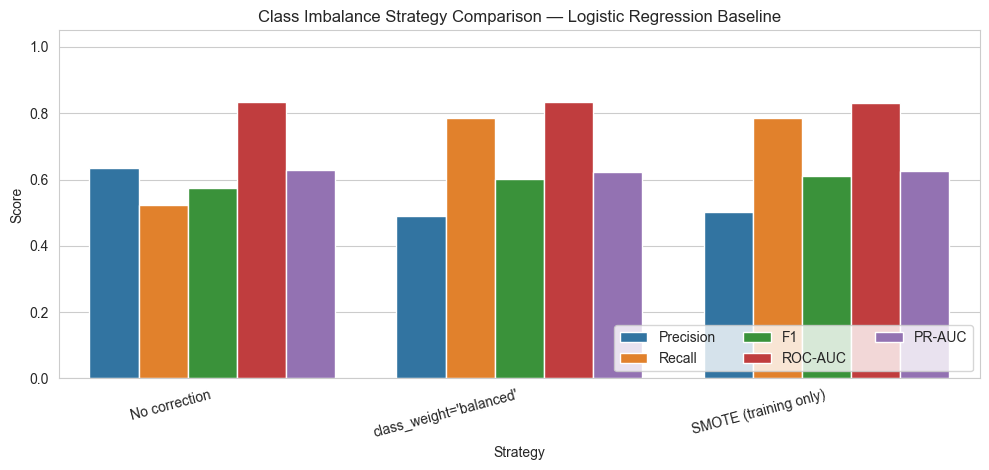

In [13]:
plot_df = imbalance_df.melt(
    id_vars='Strategy',
    value_vars=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 4.8))

sns.barplot(
    data=plot_df,
    x='Strategy',
    y='Score',
    hue='Metric'
)

plt.title('Class Imbalance Strategy Comparison — Logistic Regression Baseline')
plt.xlabel('Strategy')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right', ncol=3)
plt.tight_layout()
plt.show()

**Reading the table:**

- **No correction:** This version is more conservative. It usually gives higher Precision because it flags fewer customers as churn risks, but Recall is lower, meaning more actual churners are missed.

- **`class_weight='balanced'`:** Recall improves because the model gives more weight to the minority churn class during training. The trade-off is a small drop in Precision because more customers are flagged as potential churners.

- **SMOTE:** SMOTE gives a similar Precision–Recall pattern to `class_weight='balanced'`. Recall improves, Precision falls slightly, and F1 remains broadly similar.

**Conclusion:**

SMOTE and `class_weight='balanced'` give similar results on this dataset. Since class weighting is simpler, does not create synthetic records, and is easier to reproduce across notebooks, it is treated as the preferred first option for models that support it.

This comparison also confirms that Accuracy should not be used on its own. The modelling notebooks should report Precision, Recall, F1-score, ROC-AUC, PR-AUC and MCC so that the trade-off between missed churners and false alerts is visible.

### 3.10 Save processed file

The final processed Telco dataset is saved as `telco_processed.csv`. This file is used by NB1–NB5 for modelling. Scaling is not saved here because it must be fitted only on training data inside each modelling notebook.

In [14]:
telco.to_csv('telco_processed.csv', index=False)

print('Saved telco_processed.csv')
print(f'Shape: {telco.shape}')
print(f'Remaining missing values: {telco.isna().sum().sum()}')

class_balance = pd.DataFrame({
    'Count': telco['Churn'].value_counts().rename(index={0: 'No churn', 1: 'Churn'}),
    'Percentage': (telco['Churn'].value_counts(normalize=True).rename(index={0: 'No churn', 1: 'Churn'}) * 100).round(2)
})

print('\nClass balance in saved file:')
display(class_balance)

print(
    '\nNote: telco_processed.csv is cleaned and encoded, but not scaled. '
    'Scaling is fitted inside the individual modelling notebooks after the train/test split to avoid leakage.'
)

Saved telco_processed.csv
Shape: (7032, 39)
Remaining missing values: 0

Class balance in saved file:


,Count,Percentage
Churn,,
No churn,5163,73.42
Churn,1869,26.58



Note: telco_processed.csv is cleaned and encoded, but not scaled. Scaling is fitted inside the individual modelling notebooks after the train/test split to avoid leakage.


## 4. Pre-processing Summary

| Step | Details |
|---|---|
| Raw shape | (7,043, 21) |
| Cleaning | Dropped `customerID`; converted `TotalCharges` to numeric; dropped 11 rows with blank/non-numeric `TotalCharges` |
| Feature engineering | Added 5 features: `TenureBucket`, `ServicesCount`, `AvgMonthlySpend`, `ChargesPerService`, `IsLongTermContract` |
| Encoding | Binary mapping for Yes/No fields; one-hot encoding with `drop_first=True` for multi-category features including `TenureBucket` |
| Target | `Churn` converted to 1/0; positive class rate ≈ 0.265 |
| Class imbalance | Compared no correction, `class_weight='balanced'` and SMOTE using Logistic Regression as a quick baseline |
| PCA exploration | 2D projection shows overlap between churn and non-churn customers, so the full feature space is kept for modelling |
| Scaling | Not fitted in NB0. Scaling is fitted inside each modelling notebook after the train/test split to avoid leakage |
| Final output | `telco_processed.csv`; final shape is printed in the save cell |

### Engineered features

| Feature | Type | Source | Rationale |
|---|---|---|---|
| `TenureBucket` | one-hot encoded categorical feature | `tenure` | Captures non-linear customer lifecycle effects |
| `ServicesCount` | numeric | Service-related columns | Measures engagement breadth and possible switching effort |
| `AvgMonthlySpend` | numeric | `TotalCharges`, `tenure` | Estimates historical average monthly spend |
| `ChargesPerService` | numeric | `MonthlyCharges`, `ServicesCount` | Captures price pressure relative to the number of services held |
| `IsLongTermContract` | binary | `Contract` | Captures whether the customer is on a one-year or two-year contract |

## 5. Output file

The final processed dataset is saved as:

- `telco_processed.csv`

This file is used by the five individual modelling notebooks, NB1–NB5.

## 6. Next steps

Each individual modelling notebook should:

1. Load `telco_processed.csv`.
2. Apply the same stratified 60/20/20 train/validation/test split with `random_state=42`.
3. Train one assigned primary supervised learning model with hyperparameter tuning.
4. Train the shared Logistic Regression benchmark model using the same data split.
5. Evaluate both models on the held-out test set using the agreed metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, MCC and Overfit Gap.
6. Save the results to `results_log.csv` so NB6 can build the final group dashboard.

The shared Logistic Regression model provides a consistent benchmark across all notebooks. This allows each primary model to be compared against the same baseline.